# Twitch Viewership Curves

Explores how viewer counts evolve over the lifetime of a stream.

Data source: `~/.config/twitch-tray/data.db` (SQLite)

## Setup

Load data from SQLite into pandas. Each row is one observation: a viewer count
for a specific broadcaster at a specific `stream_age_min` (minutes since they went live).

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="darkgrid")

DB_PATH = Path.home() / ".config" / "twitch-tray" / "data.db"

con = sqlite3.connect(DB_PATH)

df = pd.read_sql("""
    SELECT
        vo.broadcaster_id,
        f.broadcaster_name AS name,
        vo.stream_age_min,
        vo.viewer_count,
        vo.stream_started_at,
        vo.observed_at
    FROM viewer_observations vo
    LEFT JOIN followed f ON f.broadcaster_id = vo.broadcaster_id
""", con)

# Use broadcaster_id as fallback name if not in followed table
df["name"] = df["name"].fillna(df["broadcaster_id"].astype(str))

# Convert epoch seconds to datetime
df["observed_at"] = pd.to_datetime(df["observed_at"], unit="s", utc=True)
df["stream_started_at"] = pd.to_datetime(df["stream_started_at"], unit="s", utc=True)

# stream_age as hours (for some plots)
df["stream_age_hr"] = df["stream_age_min"] / 60

# A unique stream session = (broadcaster_id, stream_started_at)
df["stream_id"] = df["broadcaster_id"].astype(str) + "_" + df["stream_started_at"].astype(str)

print(f"Loaded {len(df):,} observations")
print(f"  {df['broadcaster_id'].nunique()} streamers")
print(f"  {df['stream_id'].nunique()} unique stream sessions")
print(f"  stream age range: {df['stream_age_min'].min()}-{df['stream_age_min'].max()} min")
df.head()

Loaded 101,461 observations
  118 streamers
  806 unique stream sessions
  stream age range: 0-2825 min


,broadcaster_id,name,stream_age_min,viewer_count,stream_started_at,observed_at,stream_age_hr,stream_id
0,26610234,CohhCarnage,50,7146,2026-03-12 11:57:52+00:00,2026-03-12 12:48:10+00:00,0.833333,26610234_2026-03-12 11:57:52+00:00
1,160504245,39daph,411,3179,2026-03-12 05:56:37+00:00,2026-03-12 12:48:10+00:00,6.850000,160504245_2026-03-12 05:56:37+00:00
2,51115394,MidnightSumo,779,1873,2026-03-11 23:48:18+00:00,2026-03-12 12:48:10+00:00,12.983333,51115394_2026-03-11 23:48:18+00:00
3,43830727,KingGothalion,73,1430,2026-03-12 11:34:49+00:00,2026-03-12 12:48:10+00:00,1.216667,43830727_2026-03-12 11:34:49+00:00
4,61294188,AnnieFuchsia,43,708,2026-03-12 12:05:07+00:00,2026-03-12 12:48:10+00:00,0.716667,61294188_2026-03-12 12:05:07+00:00


## 1. Overall viewership curve (all streamers averaged)

What does the "average" stream look like? We bucket `stream_age_min` into
5-minute bins and plot the median viewer count with a confidence band.

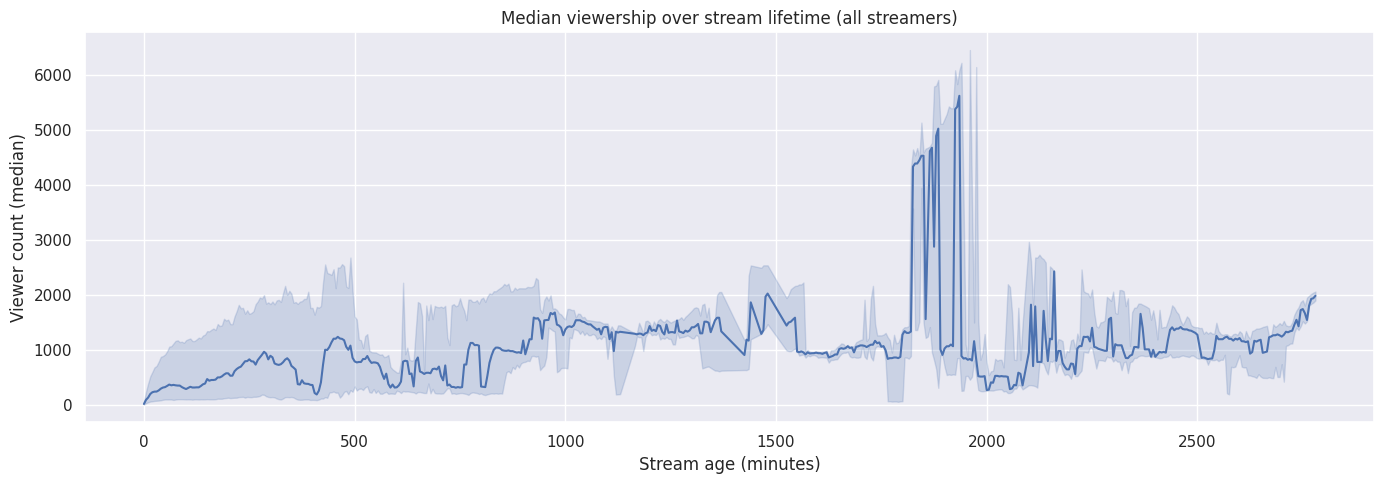

In [2]:
# Bucket into 5-min bins
df["age_bin"] = (df["stream_age_min"] // 5) * 5

# Only include bins that have enough data points
bin_counts = df.groupby("age_bin").size()
valid_bins = bin_counts[bin_counts >= 10].index
binned = df[df["age_bin"].isin(valid_bins)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=binned, x="age_bin", y="viewer_count", estimator="median",
             errorbar=("pi", 50), ax=ax)
ax.set_xlabel("Stream age (minutes)")
ax.set_ylabel("Viewer count (median)")
ax.set_title("Median viewership over stream lifetime (all streamers)")
plt.tight_layout()
plt.show()

## 2. Per-streamer ramp-up curves

Pick the streamers with the most data and overlay their individual curves.
Each line is one streamer's average viewers at each stream age.

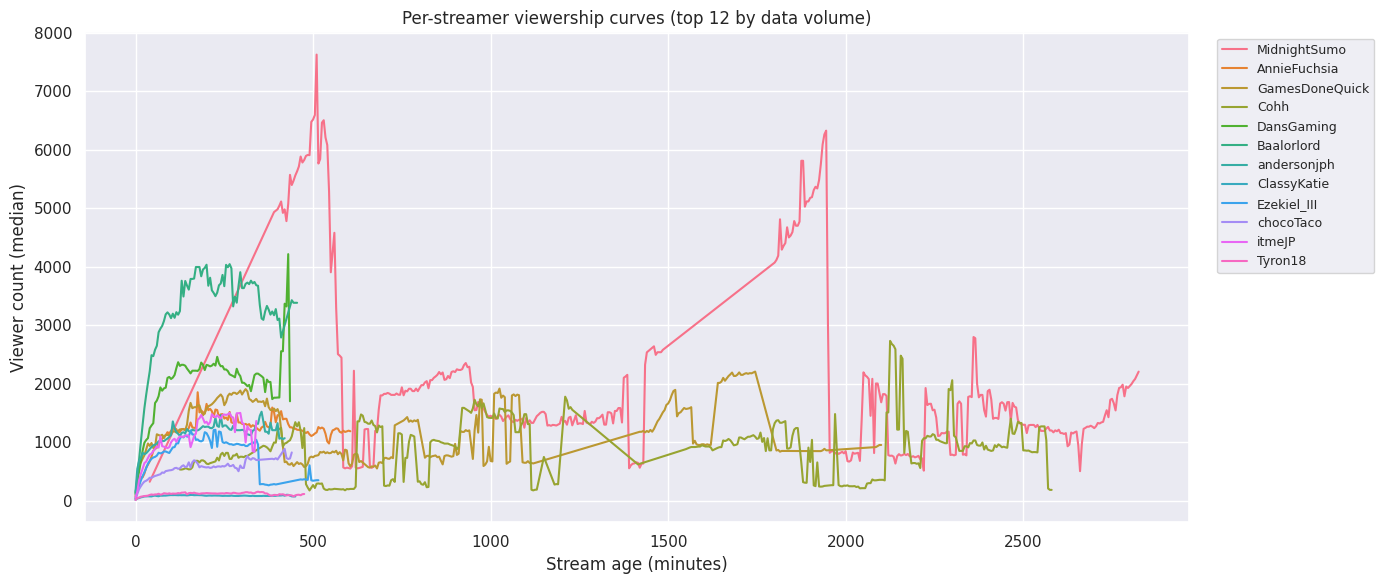

In [4]:
# Top 12 streamers by number of observations
top_streamers = df.groupby("name").size().nlargest(12).index
top_df = df[df["name"].isin(top_streamers)].copy()
top_df["age_bin"] = (top_df["stream_age_min"] // 5) * 5

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=top_df, x="age_bin", y="viewer_count", hue="name",
             estimator="median", errorbar=None, ax=ax)
ax.set_xlabel("Stream age (minutes)")
ax.set_ylabel("Viewer count (median)")
ax.set_title("Per-streamer viewership curves (top 12 by data volume)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Normalized ramp-up (% of peak)

To compare shapes across streamers with very different audience sizes,
normalize each streamer's curve to their peak viewer count. This reveals
whether small and large streamers have different ramp-up shapes.

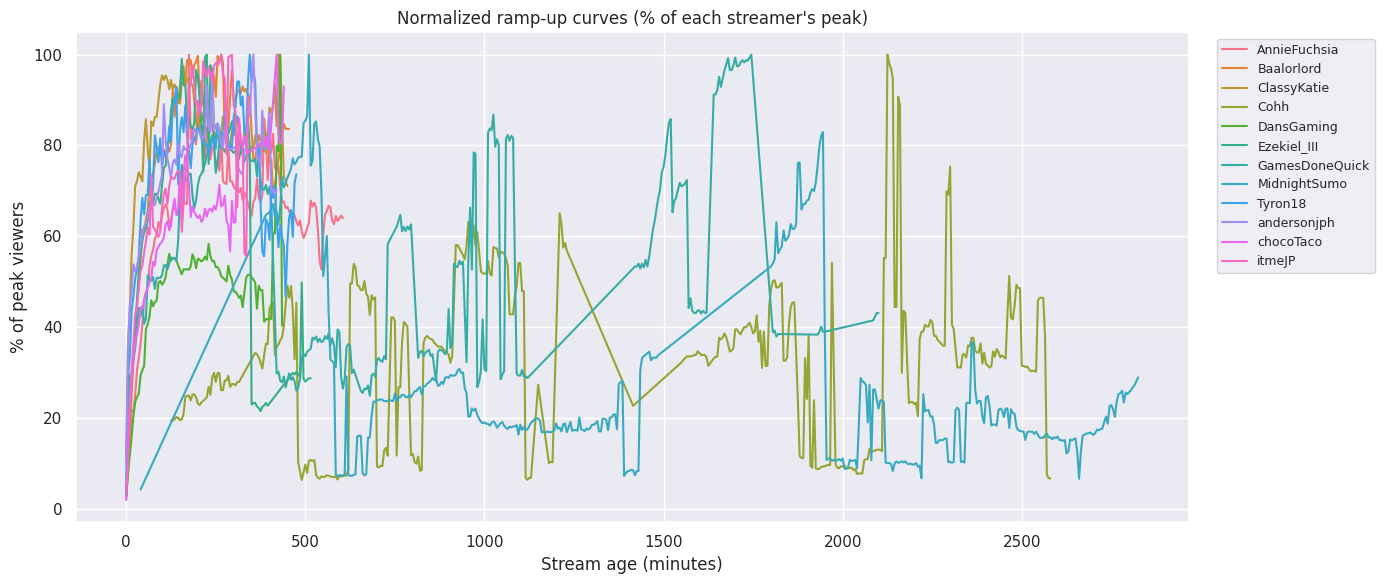

In [6]:
# Per-streamer median at each age bin
curves = (top_df.groupby(["name", "age_bin"])["viewer_count"]
          .median().reset_index())

# Normalize to each streamer's peak
peaks = curves.groupby("name")["viewer_count"].transform("max")
curves["pct_of_peak"] = curves["viewer_count"] / peaks * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=curves, x="age_bin", y="pct_of_peak", hue="name",
             ax=ax)
ax.set_xlabel("Stream age (minutes)")
ax.set_ylabel("% of peak viewers")
ax.set_title("Normalized ramp-up curves (% of each streamer's peak)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Time to stabilization

How long does it take for a stream's viewership to "settle"?

We define stabilization as the first 5-min bin where the rolling coefficient
of variation (stddev/mean over a 30-min window) drops below 0.15.
Streamers who never stabilize (very volatile) will show as missing.

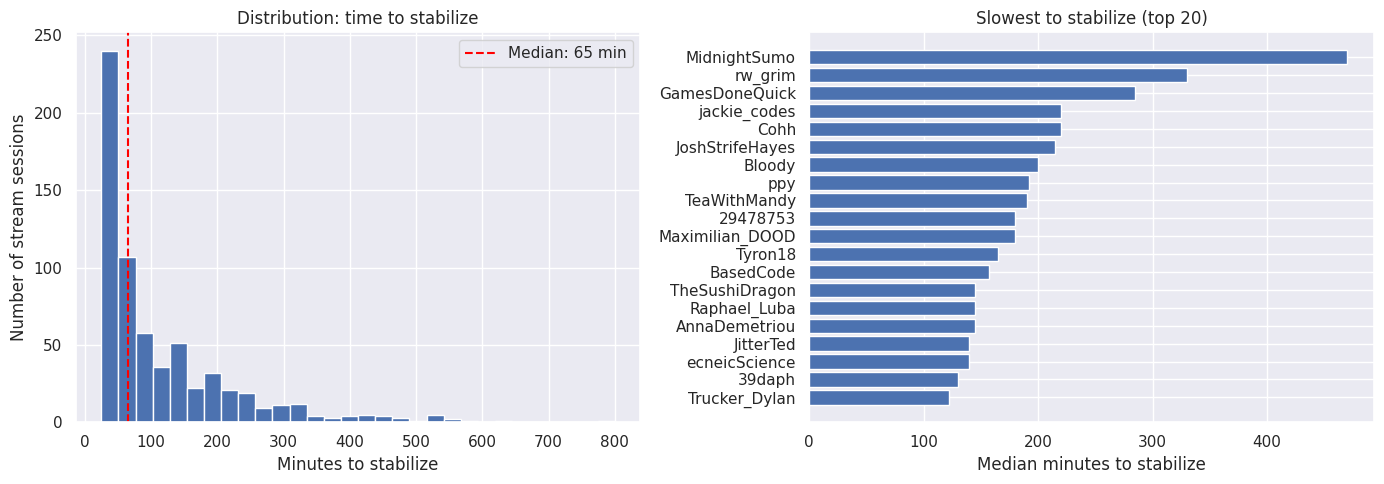


Overall median time to stabilize: 65 min
Sessions that stabilized: 652 / 806


In [7]:
# Per-session curves: median viewer count at each age bin
session_curves = (df.groupby(["name", "stream_id", "age_bin"])["viewer_count"]
                  .median().reset_index()
                  .sort_values(["name", "stream_id", "age_bin"]))

# Rolling CV per stream session
window = 6  # 6 bins * 5 min = 30 min window
cv_threshold = 0.15

stabilization_times = []
for (name, sid), group in session_curves.groupby(["name", "stream_id"]):
    if len(group) < window:
        continue
    rolling_mean = group["viewer_count"].rolling(window).mean()
    rolling_std = group["viewer_count"].rolling(window).std()
    cv = rolling_std / rolling_mean
    stable = cv.dropna()[cv.dropna() < cv_threshold]
    if not stable.empty:
        stable_idx = stable.index[0]
        stabilization_times.append({
            "name": name,
            "stream_id": sid,
            "stabilized_at_min": group.loc[stable_idx, "age_bin"]
        })

stab_df = pd.DataFrame(stabilization_times)
if not stab_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram of stabilization times
    axes[0].hist(stab_df["stabilized_at_min"], bins=30, edgecolor="white")
    axes[0].set_xlabel("Minutes to stabilize")
    axes[0].set_ylabel("Number of stream sessions")
    axes[0].set_title("Distribution: time to stabilize")
    axes[0].axvline(stab_df["stabilized_at_min"].median(), color="red",
                    linestyle="--", label=f'Median: {stab_df["stabilized_at_min"].median():.0f} min')
    axes[0].legend()

    # Per-streamer median stabilization time
    per_streamer = stab_df.groupby("name")["stabilized_at_min"].median().sort_values()
    top_20 = per_streamer.tail(20)  # show the 20 slowest-to-stabilize
    axes[1].barh(top_20.index, top_20.values)
    axes[1].set_xlabel("Median minutes to stabilize")
    axes[1].set_title("Slowest to stabilize (top 20)")

    plt.tight_layout()
    plt.show()

    print(f"\nOverall median time to stabilize: {stab_df['stabilized_at_min'].median():.0f} min")
    print(f"Sessions that stabilized: {len(stab_df)} / {session_curves['stream_id'].nunique()}")
else:
    print("Not enough data to compute stabilization times yet.")

## 5. Individual stream sessions

Pick a specific streamer and plot each of their stream sessions as a
separate line. This shows session-to-session variability.

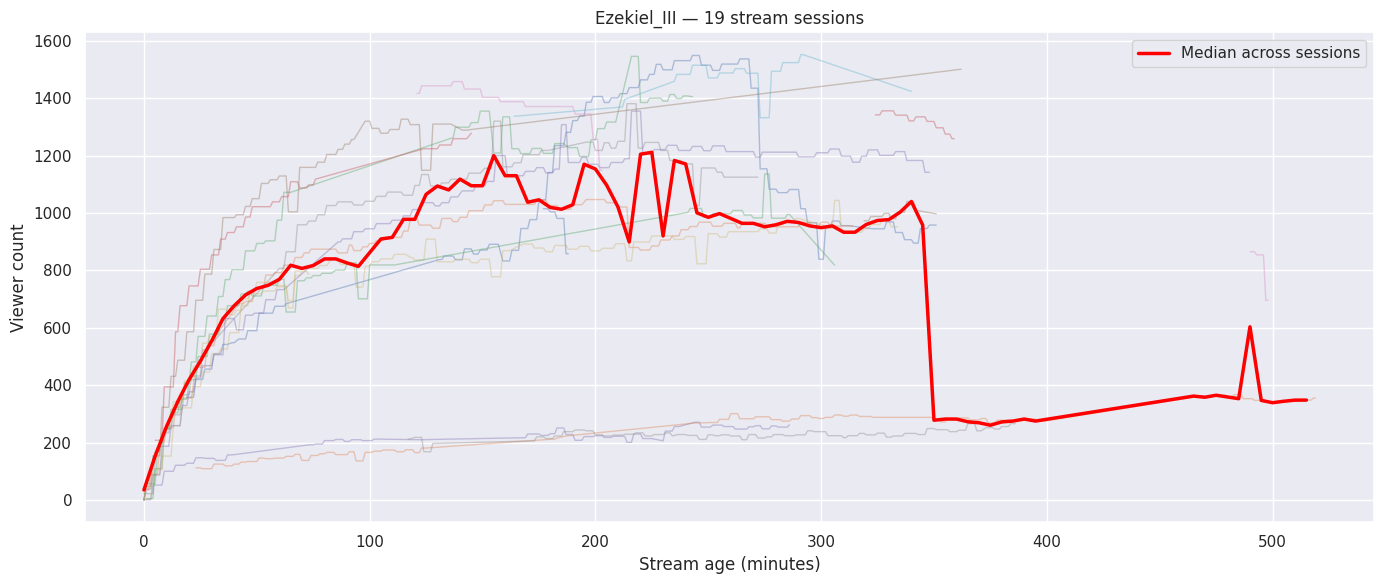

In [13]:
# Change this to any streamer name from your data
STREAMER = "Ezekiel_III" # df.groupby("name").size().idxmax()  # default: most data

streamer_df = df[df["name"] == STREAMER].copy()
n_sessions = streamer_df["stream_id"].nunique()

fig, ax = plt.subplots(figsize=(14, 6))
for sid, group in streamer_df.groupby("stream_id"):
    ax.plot(group["stream_age_min"], group["viewer_count"], alpha=0.4, linewidth=1)

# Overlay the median curve
median_curve = streamer_df.groupby("age_bin")["viewer_count"].median()
ax.plot(median_curve.index, median_curve.values, color="red", linewidth=2.5,
        label="Median across sessions")

ax.set_xlabel("Stream age (minutes)")
ax.set_ylabel("Viewer count")
ax.set_title(f"{STREAMER} — {n_sessions} stream sessions")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Streamer comparison heatmap

For each streamer, compute the median viewer count at each hour mark.
The heatmap makes it easy to spot which streamers ramp fast vs slow,
and which sustain viewers longest.

In [ ]:
# Bucket by hour
df["age_hour"] = df["stream_age_min"] // 60

# Streamers with at least 200 observations
enough_data = df.groupby("name").size()
viable = enough_data[enough_data >= 200].index

heat_df = (df[df["name"].isin(viable)]
           .groupby(["name", "age_hour"])["viewer_count"]
           .median().reset_index())

# Only show hours that most streamers have data for
hour_coverage = heat_df.groupby("age_hour")["name"].nunique()
good_hours = hour_coverage[hour_coverage >= 3].index
heat_df = heat_df[heat_df["age_hour"].isin(good_hours)]

pivot = heat_df.pivot(index="name", columns="age_hour", values="viewer_count")

# Normalize each row to [0,1] for comparability
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot_norm) * 0.35)))
sns.heatmap(pivot_norm, cmap="YlOrRd", ax=ax, xticklabels=True,
            cbar_kws={"label": "% of peak viewers"})
ax.set_xlabel("Stream age (hours)")
ax.set_ylabel("")
ax.set_title("Viewership intensity by stream age (normalized per streamer)")
plt.tight_layout()
plt.show()

## 7. Summary statistics

Per-streamer summary: median viewers, peak viewers, typical stream length,
number of sessions observed.

In [ ]:
summary = df.groupby("name").agg(
    sessions=("stream_id", "nunique"),
    observations=("viewer_count", "count"),
    median_viewers=("viewer_count", "median"),
    peak_viewers=("viewer_count", "max"),
    typical_length_hr=("stream_age_min", lambda x: x.max() / 60),
).sort_values("median_viewers", ascending=False)

summary["typical_length_hr"] = summary["typical_length_hr"].round(1)
summary["median_viewers"] = summary["median_viewers"].astype(int)
summary["peak_viewers"] = summary["peak_viewers"].astype(int)

print(f"Streamers tracked: {len(summary)}")
print(f"Total observations: {len(df):,}")
print()
summary.head(30)